# Regression

## 1.Simple linear regression

In [99]:
# linear reg with  sklearn 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

df = pd.read_csv("DATASET/height_weight_dataset.csv")

X = df[['Height_cm']]
y = df['Weight_kg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 1.5721559447705573
MSE : 4.010932585251725
RMSE: 2.0027312813384937
R²  : 0.9920051175577391


In [102]:
# linear reg using OLS 
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 121.6 kB/s  0:01:23a 0:00:020:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]


In [103]:
import statsmodels.api as sm

In [104]:
model =sm.OLS(y_train,X_train).fit()

In [105]:
predict =model.predict(X_test)

In [106]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              Weight_kg   R-squared (uncentered):                   0.980
Model:                            OLS   Adj. R-squared (uncentered):              0.979
Method:                 Least Squares   F-statistic:                              748.1
Date:                Fri, 03 Jul 2026   Prob (F-statistic):                    3.25e-14
Time:                        19:15:16   Log-Likelihood:                         -59.840
No. Observations:                  16   AIC:                                      121.7
Df Residuals:                      15   BIC:                                      122.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [107]:
lr.predict([[152]])

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([43.95867297])

## 2.multiple linear regression

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [55]:
df =pd.read_csv("DATASET/multiple_linear_regression_dataset.csv")
df.head(2)

,age,experience,income
0,25,1,30450
1,30,3,35670


In [56]:
df.isnull().sum()

age           0
experience    0
income        0
dtype: int64

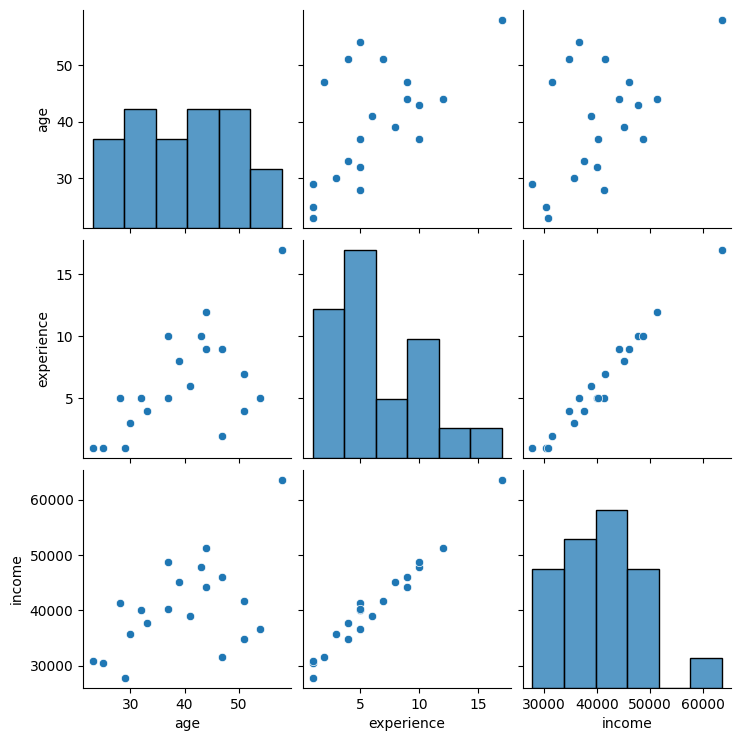

In [57]:
sns.pairplot(df)

In [58]:
df.corr()

,age,experience,income
age,1.000000,0.615165,0.532204
experience,0.615165,1.000000,0.984227
income,0.532204,0.984227,1.000000


In [59]:
# specify independent and dependent feature
X = df[['age','experience']] # df.iloc[:,: -1]
y =df['income'] #df.iloc[:,-1]

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.25,random_state=42)


<Axes: xlabel='age', ylabel='income'>

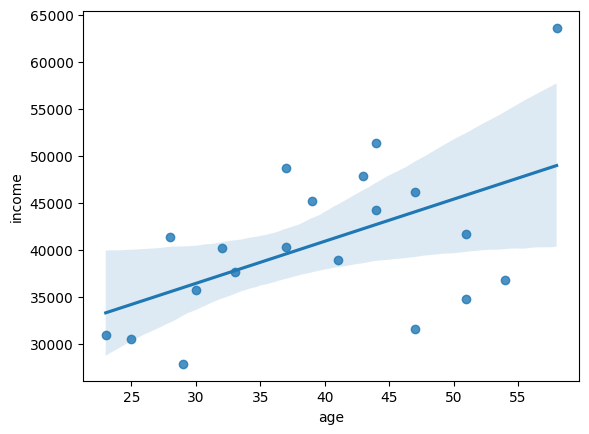

In [61]:
sns.regplot(data = df,x=df['age'],y=df['income'])

<Axes: xlabel='experience', ylabel='income'>

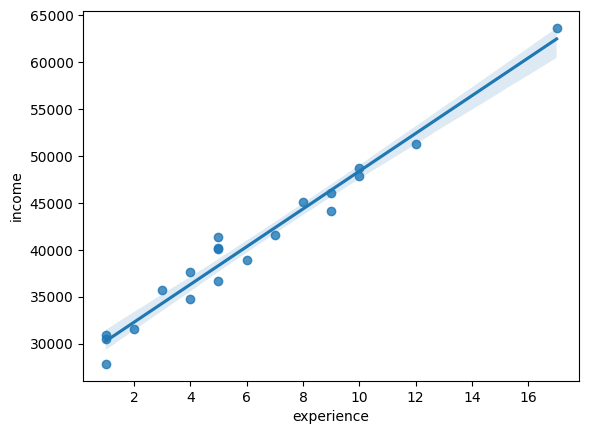

In [62]:
sns.regplot(data = df,x=df['experience'],y=df['income'])

In [63]:
from sklearn.preprocessing import StandardScaler
sc =StandardScaler()
X_train =sc.fit_transform(X_train)
X_test =sc.transform(X_test)

In [64]:
X_train

array([[ 0.954958  , -0.04975186],
       [ 0.50732144,  0.44776674],
       [-1.17131567, -0.54727045],
       [ 0.17159402,  0.44776674],
       [ 1.73832199,  2.43784112],
       [ 0.954958  , -0.79602975],
       [ 0.50732144, -1.29354835],
       [-0.38795169,  0.19900744],
       [-0.61176997,  0.69652603],
       [ 0.05968488,  0.69652603],
       [ 1.29068542, -0.54727045],
       [-1.05940653, -0.79602975],
       [-1.5070431 , -1.54230764],
       [ 0.17159402,  1.19404463],
       [-1.61895224, -0.54727045]])

In [65]:
# train your model 
from sklearn.linear_model import LinearRegression
reg =LinearRegression(n_jobs=2)
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,2
,positive,False


In [66]:
# cross val score 
from sklearn.model_selection import cross_val_score
cross = cross_val_score(reg,X_train,y_train,scoring='r2',cv =3)
np.mean(cross)

np.float64(0.9684666566064507)

In [67]:
# prediction
y_pred=reg.predict(X_test)

In [68]:
y_pred

array([30811.24112044, 31001.40881574, 40113.19801384, 34665.14126451,
       38328.87371328])

In [69]:
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error,mean_squared_error

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 926.3665944472938
MSE : 1264016.0265139719
RMSE: 1124.2846732540527
R²  : 0.9217045189228629


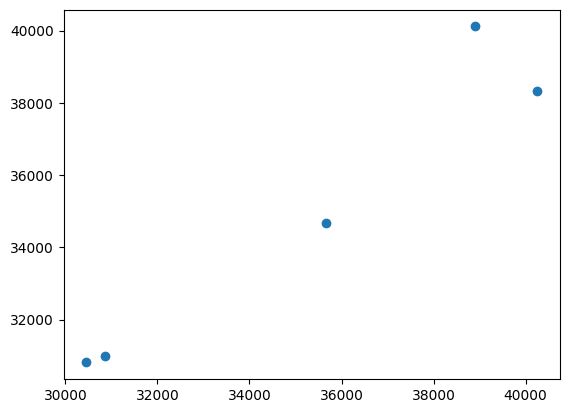

In [70]:
plt.scatter(y_test,y_pred)

In [71]:
# calculate the residual
residual =y_test - y_pred
residual

0     -361.241120
17    -131.408816
15   -1213.198014
1     1004.858735
8     1921.126287
Name: income, dtype: float64

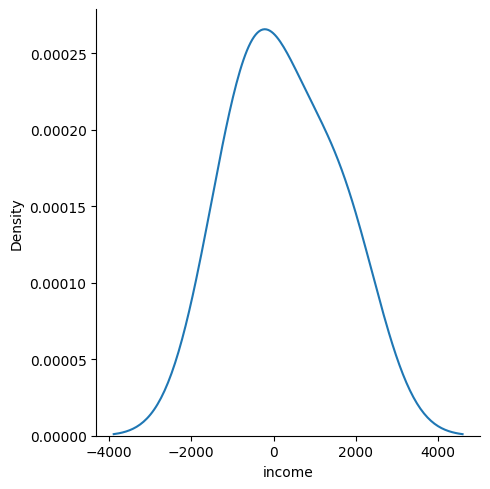

In [72]:
# plot the residual 
sns.displot(residual,kind='kde')

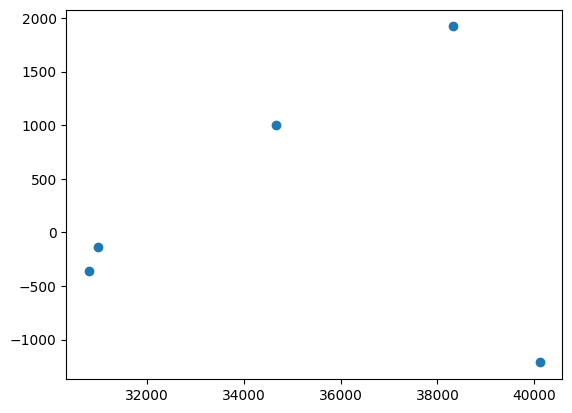

In [73]:
# create a scatter plot with respect to prediction and residual
plt.scatter(y_pred,residual)

In [74]:
# use ols method 
import statsmodels.api as sm
model =sm.OLS(y_train,X_train).fit()

In [75]:
model.summary()

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 income   R-squared (uncentered):                   0.037
Model:                            OLS   Adj. R-squared (uncentered):             -0.111
Method:                 Least Squares   F-statistic:                             0.2499
Date:                Mon, 06 Jul 2026   Prob (F-statistic):                       0.783
Time:                        18:13:08   Log-Likelihood:                         -181.17
No. Observations:                  15   AIC:                                      366.3
Df Residuals:                      13   BIC:                                      367.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -849.6522   1.33e+04     -0.064      0.950   -2.95e+04    2.78e+04
x2          8701.8243   1.33e+04      0.656      0.523   -1.99e+04    3.73e+04
==============================================================================
Omnibus:                        0.894   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.640   Jarque-Bera (JB):                0.699
Skew:                          -0.471   Prob(JB):                        0.705
Kurtosis:                       2.521   Cond. No.                         1.63
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [76]:
reg.coef_

array([-849.65219971, 8701.82426324])

In [77]:
reg.intercept_

np.float64(42571.333333333336)

## 3. polynomial linear regression

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [80]:
df =pd.read_csv("DATASET/Ice_cream selling data.csv")
df.head(2)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120


In [81]:
# define X and y
X =df[['Temperature (°C)']]
y =df['Ice Cream Sales (units)']

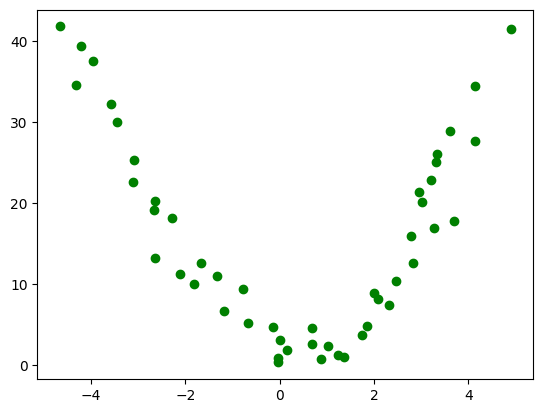

In [83]:
plt.scatter(X,y,color='green')

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [86]:
# linear reg
from sklearn.linear_model import LinearRegression
model_lr =LinearRegression()
model_lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,model_lr.predict(X_test))
r2

-0.24630892029337303

Text(0, 0.5, 'y')

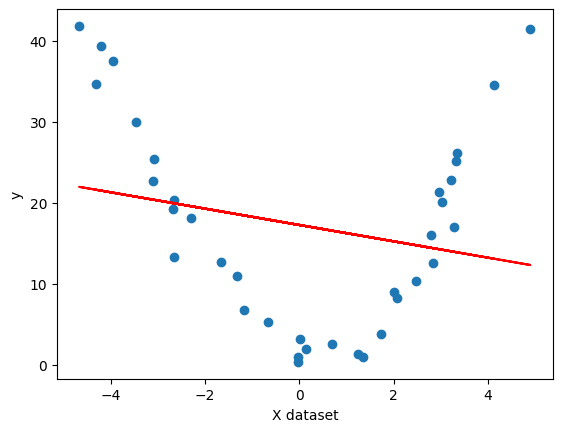

In [90]:
# visualize the model_lr
plt.scatter(X_train,y_train)
plt.plot(X_train,model_lr.predict(X_train),color='red')
plt.xlabel("X dataset")
plt.ylabel("y")

In [121]:
# apply the polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3,include_bias=True)

In [122]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly =poly.transform(X_test)

In [123]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
model_poly = LinearRegression()
model_poly.fit(X_train_poly,y_train)
y_pred = model_poly.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.8715616916590967


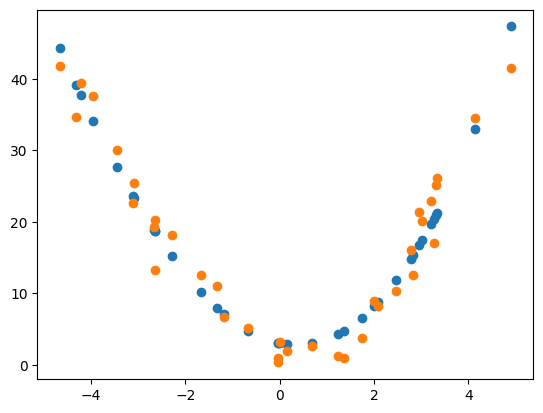

In [124]:
plt.scatter(X_train,model_poly.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [125]:
print(model_poly.coef_)
print(model_poly.intercept_)

[ 0.         -1.3516187   1.85630202  0.05386544]
3.047242868757971


In [128]:
# prediction of new data
X_new =np.linspace(-3,3,200).reshape(200,1)
X_new_poly =poly.transform(X_new)
X_new_poly

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

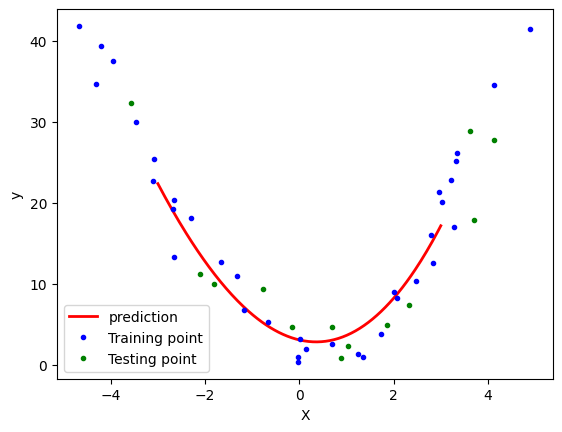

In [129]:
# predict and visualize 
y_new =model_poly.predict(X_new_poly)
plt.plot(X_new,y_new,"r-",linewidth=2,label='prediction')
plt.plot(X_train,y_train,"b.",label ='Training point')
plt.plot(X_test,y_test,"g.",label ='Testing point')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [130]:
# pipeline concept in polynomial regression
from sklearn.pipeline import Pipeline


In [134]:
# create a function for polynomial regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

def plot_polynomial_regression(degree: int) -> None:
    """Trains a polynomial regression model and plots its prediction curve.

    Args:
        degree (int): The degree of the polynomial features to generate.
    """
    # 1. Generate feature points for the smooth prediction curve
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    # 2. Define the pipeline components
    poly_feature = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    
    poly_regression = Pipeline([
        ("poly_feature", poly_feature),
        ("lin_reg", lin_reg)
    ])
    
    # 3. Fit the model and make predictions
    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict(X_new)
    
    # 4. Configure and display the plot
    plt.figure(figsize=(8, 5))
    
    # Plot prediction curve and actual data points
    plt.plot(X_new, y_pred_new, color='red', linestyle='-', linewidth=3, label=f"Degree {degree}")
    plt.plot(X_train, y_train, "b.", markersize=8, label="Train Data")
    plt.plot(X_test, y_test, "g.", markersize=8, label="Test Data")
    
    # Labeling and formatting
    plt.xlabel("X", fontsize=11)
    plt.ylabel("y", fontsize=11)
    plt.title(f"Polynomial Regression Fitting (Degree {degree})", fontsize=12, fontweight='bold')
    plt.axis([-4, 4, 0, 10])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc="upper left")
    
    plt.show()


/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


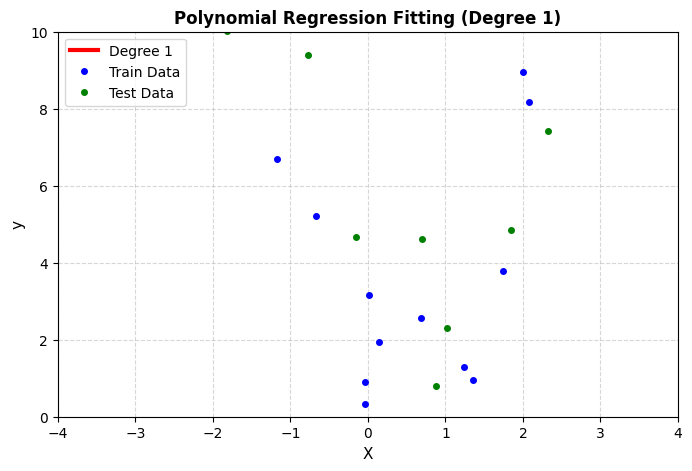

In [137]:
plot_polynomial_regression(1)

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


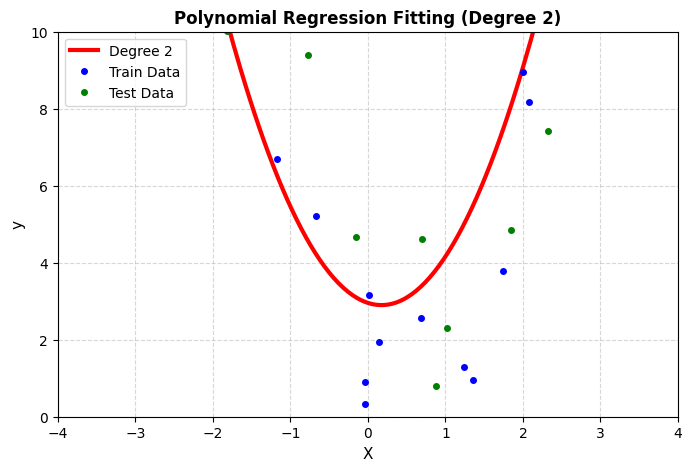

In [138]:
plot_polynomial_regression(2)

/home/tushar/Desktop/MLandDL/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


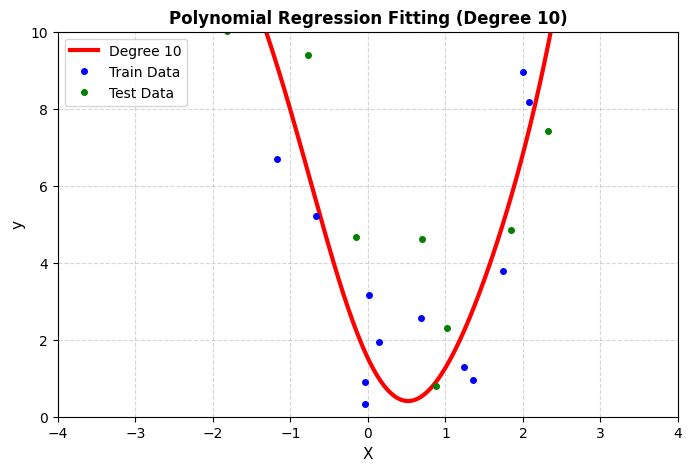

In [143]:
plot_polynomial_regression(10)